# Семинар 13

# Stochastic Optimization 1: Intro to Stochatstic Optimization

## 1. Intro to PyTorch

In [1]:
import numpy as np
import copy
import time
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import torch
from torch import nn
from torch.optim import Optimizer

In [3]:
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms

In [4]:
matplotlib.use('Agg')
params = {'legend.fontsize': 20,
          'legend.handlelength': 4,
          "axes.labelsize": 45,
          "xtick.labelsize": 25,
          "ytick.labelsize": 25,
          "lines.linewidth": 4,
           "axes.titlesize":30}
matplotlib.rcParams.update(params)

Примеры создания тензоров:

In [5]:
x = torch.rand(10)
y = torch.zeros(10)
z = torch.randn((10, 10))

Пример создания тензоров, по которым нужно дифференцировать:

In [6]:
w = torch.randn((10), requires_grad=True)
w0 = torch.randn(1, requires_grad=True)

Вычислим функцию $f(w, w_0) = \langle w, x\rangle +w_0$:

In [7]:
def f(w, w0, x):
    return torch.dot(w, x) + w0

In [8]:
value = f(w, w0, x)
value

tensor([-1.2778], grad_fn=<AddBackward0>)

Продифференцируем:

In [9]:
value.backward()

In [10]:
w.grad

tensor([0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
        0.4311])

In [11]:
x

tensor([0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
        0.4311])

In [12]:
value = f(w, w0, x)
value.backward()
w0.grad

tensor([2.])

Аккумуляция градиента:

In [13]:
for i in range(5):
    value = f(w, w0, x)
    value.backward()
    print(w0.grad)

tensor([3.])
tensor([4.])
tensor([5.])
tensor([6.])
tensor([7.])


Использования `nn.Module`:

In [14]:
class Model(nn.Module):
    def __init__(self, input_size):
        super(Model, self).__init__()
        self.layer = nn.Linear(input_size, 1)

    def forward(self, x):
        return self.layer(x)

In [15]:
model = Model(x.shape[0])
for i in range(5):
    value = torch.sum(model(x))
    value.backward()
    print(model.layer.weight.grad)

tensor([[0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
         0.4311]])
tensor([[0.6041, 1.2760, 0.0525, 1.7229, 1.5149, 1.3249, 0.1701, 1.1370, 0.6768,
         0.8623]])
tensor([[0.9062, 1.9139, 0.0787, 2.5844, 2.2724, 1.9874, 0.2552, 1.7055, 1.0151,
         1.2934]])
tensor([[1.2083, 2.5519, 0.1050, 3.4458, 3.0299, 2.6498, 0.3403, 2.2740, 1.3535,
         1.7246]])
tensor([[1.5104, 3.1899, 0.1312, 4.3073, 3.7874, 3.3123, 0.4253, 2.8425, 1.6919,
         2.1557]])


Зануляем градиенты после каждой итерации:

In [16]:
model = Model(x.shape[0])
for i in range(5):
    value = torch.sum(model(x))
    value.backward()
    print(model.layer.weight.grad)
    model.zero_grad()

tensor([[0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
         0.4311]])
tensor([[0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
         0.4311]])
tensor([[0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
         0.4311]])
tensor([[0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
         0.4311]])
tensor([[0.3021, 0.6380, 0.0262, 0.8615, 0.7575, 0.6625, 0.0851, 0.5685, 0.3384,
         0.4311]])


## 2. Постановка задачи

Минимизация математического ожидания:

$$f(\mathbf{w}) = \mathbb{E}_\xi F(\mathbf{w}, \xi)\rightarrow \min_{\textbf{w}\in\mathbb{R}^n}$$

Минимизация сумма функций:

$$F(w)=\frac{1}{M}\sum_{i=1}^M f_i(\textbf{w}) \rightarrow \min_{\textbf{w}\in\mathbb{R}^n},$$
где $f_i$ - гладкие функции.

Примеры:

- максимизация логарифма правдоподобия: $$\ln L(\{\textbf{x}_i\}, \theta) = \sum_{i=1}^M \ln p_\theta(\textbf{x}_i)\rightarrow \max_{\theta}$$

- задачи классификации / регрессии: $$\frac{1}{M}\sum_{i=1}^M f((\textbf{x}_i, \textbf{y}_i), \textbf{w}) \rightarrow \min_{\textbf{w}\in\mathbb{R}^n},$$


In [17]:
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_testset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.14MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 10.2MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [102]:
X_ = []
Y_ = []
for x, y in mnist_trainset:
      X_.append(x.view(-1))
      Y_.append(y)
X = torch.stack(X_)
Y = torch.tensor(Y_).view(-1).to(float)

In [103]:
X_ = []
Y_ = []
for x, y in mnist_testset:
      X_.append(x.view(-1))
      Y_.append(y)
X_test = torch.stack(X_)
Y_test = torch.tensor(Y_).view(-1).to(float)

In [104]:
print("Shape of X train", X.shape)
print("Shape of X test", X_test.shape)
print("Sparsity of X train", (torch.sum(torch.abs(X)>=1e-12)/(X.shape[0] * X.shape[1])).item())

Shape of X train torch.Size([60000, 784])
Shape of X test torch.Size([10000, 784])
Sparsity of X train 0.1912022978067398


## 3. SGD

GD:

$$x_{k+1} = x_k - \alpha_k \nabla f(x_k)$$

SGD:

$$x_{k+1} = x_k - \alpha_k \nabla f_i(x_k),$$
где $i$ - случайно выбранный элемент множества индексов $[n]$

или SGD (with batch):

$$x_{k+1} = x_k - \alpha_k  \frac{1}{m}\sum_{i\in \mathcal{I_k}}\nabla f_i(x_k),$$
где $\mathcal{I_k}$ случайно выбранное подмножество $[n]$ размера $m$ (размер батча).

$$\min f(x) = \mathbb{E}F(x,\xi)$$

$$\sigma^2_m = Var\left(\frac{1}{m}\sum_{i=1}^m \nabla F(x, \xi_i)\right)=\frac{1}{m^2}\sum_{i=1}^m Var\left(\nabla F(x, \xi_i)\right)\leq \frac{\sigma^2}{m}$$


Если $ Var\left( \nabla F(x^*, \xi_i)\right)=0$

### Скорость сходимости:

$$f(x_k) - f(x^*) \leq \frac{R}{\alpha_k k}+\frac{\alpha_k \sigma^2}{2},$$
где $Var(h_k)\leq \sigma,$ $\alpha_k\leq \frac{1}{L}$

In [105]:
class SGD_base(Optimizer):
    def __init__(self, params, lr=None):
        """
        Args:
            params (iterable): an iterable of :class:`torch.Tensor` s or
                :class:`dict` s. Specifies what Tensors should be optimized.
            lr (float): learning rate
        """
        if lr is None or lr <= 0:
            raise Exception("Learning Rate should be positive")
        self.lr = lr
        defaults = dict(lr=lr)
        super(SGD_base, self).__init__(params, defaults)

    def step(self):
        """
        Method for one optimization step
        """
        for group in self.param_groups:
            model_parameters = group["params"]
            lr = group["lr"]
            for param in model_parameters:
                h = torch.clone(param.grad).detach()
                param.data.add_(h, alpha=-lr)

$f(x)->\nabla f(x)$

$x_1:=x+\nabla f(x)$

Вы хотите: $f(x_1)->\nabla f(x_1)$, если сделаете ```detach``` для градиента

Без ```detach``` 
$f(x_1).backward -> \nabla_x f(x + \nabla f(x)) = \nabla f(x_1) + \nabla^2 f(x) \nabla f(x_1)$

## 4. Эксперименты: SGD

Бинарная Кросс-Энтропия:

$$f(\mathbf{w})=\frac{1}{m}\sum\limits_{i=1}^m l((\mathbf{x}_i, y_i), \mathbf{w})$$

Слагаемые:

$$l((\mathbf{x}_i, y_i), \mathbf{w}) = -y_i \log\left(nn_\mathbf{w}(\mathbf{x}_i)\right) - (1-y_i) \log\left(1-nn_\mathbf{w}(\mathbf{x}_i)\right)$$

Модель:

$$nn_\mathbf{w}(\mathbf{x}) = \sigma(\langle \mathbf{x}, \mathbf{w}\rangle + w_0)$$

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

In [106]:
class LinearModel(nn.Module):
    def __init__(self, input_size):
        """
        Initialization of Linear Model
        :param input_size: int, dimension of input vector
        """
        super(LinearModel, self).__init__()
        self.layer = nn.Linear(input_size, 1)

    def forward(self, x):
        return torch.sigmoid(self.layer(x))


def init_model(n):
    """
    :param n: int, input size for Linear Model
    :return: Linear Model with input size n
    """
    torch.manual_seed(0)
    return LinearModel(n)

$\text{sigmoid}(w^\top (\text{relu}(W_1 x + b_0))$

$$relu(x) = \max(0, x)$$

In [107]:
class TwoLayerModel(nn.Module):
    def __init__(self, input_size):
        """
        Initialization of Linear Model
        :param input_size: int, dimension of input vector
        """
        super(TwoLayerModel, self).__init__()
        self.layer = nn.Linear(input_size, 100)
        self.layer1 = nn.Linear(100, 10)

    def forward(self, x):
        x = torch.relu(self.layer(x))
        x = self.layer1(x)
        return x


def init_two_layer_model(n):
    """
    :param n: int, input size for Linear Model
    :return: Two Layer Model with input size n
    """
    torch.manual_seed(0)
    return TwoLayerModel(n)

In [108]:
m, n = X.shape

### 4.1. Training Loop

In [109]:
def get_batch_indexes(n, batch_size):
    """
    :param batch_size: int, batch size
    :param n: int, the size of full dataset
    :return: list of batches
    """
    indexes = np.arange(n)
    indexes = np.random.permutation(indexes)
    batches = np.array_split(indexes, n//batch_size)
    return batches

In [110]:
def update_logs(logs, iteration, train_loss, test_loss, time_val):
    """
    :param logs: dict, dictionary for logs
    :param iteration: int, number of iteration
    :param train_loss: float, value of loss on train dataset
    :param test_loss: float, value of loss on test dataset
    :param time_val: float, time from training start
    :return:
    """
    logs['iter'].append(iteration)
    logs['train_loss'].append(train_loss)
    logs['test_loss'].append(test_loss)
    logs['time'].append(time_val)

In [111]:
def train(model, X, Y, loss, num_iters,
          optimizer, batch_size,
          scheduler=None,
          X_test=None, Y_test=None):
    """
    :param model: nn.Module, model that should be trained
    :param X: torch.tensor, train dataset, input of model
    :param Y: torch.tensor, train dataset, target for model
    :param loss: callable, that takes model output with target and returns differntiable loss
    :param num_iters: int, number of iterations
    :param optimizer: optimizer with method step
    :param batch_size: int, batch size
    :param scheduler: scheduler that change lr size
    :param X_test: torch.tensor, test dataset, input of model
    :param Y_test: torch.tensor, test dataset, target for model
    :return: trained model and logs
    """
    n = X.shape[0]
    logs = defaultdict(list)
    t0 = time.time()
    for i in range(num_iters):
        batch = np.random.choice(n, batch_size, False)
        X_batch, Y_batch = X[batch], Y[batch]
        loss_value = loss(model(X_batch), Y_batch)
        loss_value.backward()
        optimizer.step()
        optimizer.zero_grad()

        if scheduler is not None:
            scheduler.step()
        with torch.no_grad():
            train_loss = loss(model(X), Y).cpu().item()
            if X_test is not None:
                test_loss = loss(model(X_test), Y_test).cpu().item()
            else:
                test_loss = None
        update_logs(logs, i, train_loss, test_loss, time.time() - t0)
    return model, logs

$f_1(x) + f_2(x)$

$x^* -> \{x^* - \alpha \nabla f_1(x^*), x^* - \alpha \nabla f_2(x^*)\}$

$1,2,1,2,1,2$

In [182]:
def train_epochs(model, X, Y, loss, num_epochs,
          optimizer, batch_size,
          scheduler=None,
          X_test=None, Y_test=None):
    """
    :param model: nn.Module, model that should be trained
    :param X: torch.tensor, train dataset, input of model
    :param Y: torch.tensor, train dataset, target for model
    :param loss: callable, that takes model output with target and returns differntiable loss
    :param num_epochs: int, number of epochs
    :param optimizer: optimizer with method step
    :param batch_size: int, batch size
    :param scheduler: scheduler that change lr size
    :param X_test: torch.tensor, test dataset, input of model
    :param Y_test: torch.tensor, test dataset, target for model
    :return: trained model and logs
    """
    n = X.shape[0]
    logs = defaultdict(list)
    t0 = time.time()
    for i in range(num_epochs):
        batches = get_batch_indexes(n, batch_size)
        for batch in batches:
            X_batch, Y_batch = X[batch], Y[batch]
            loss_value = loss(model(X_batch), Y_batch)
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()
        with torch.no_grad():
            train_loss = loss(model(X), Y).cpu().item()
            if X_test is not None:
                test_loss = loss(model(X_test), Y_test).cpu().item()
            else:
                test_loss = None
        update_logs(logs, i, train_loss, test_loss, time.time() - t0)
    return model, logs

In [130]:
epochs = 50
batch_size = 128

In [131]:
device = torch.device("cuda")

In [132]:
model = init_two_layer_model(n).to(device)
optimizer = SGD_base(model.parameters(), lr=0.5)
_, logs_epochs = train_epochs(model, X.to(device), Y.to(device).view(-1).to(torch.long), nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size)

In [133]:
model = init_two_layer_model(n).to(device)
optimizer = SGD_base(model.parameters(), lr=0.5)
_, logs_iters = train(model, X.to(device), Y.to(device).to(torch.long), nn.CrossEntropyLoss(), epochs * (m//batch_size), optimizer,
                      batch_size=batch_size)

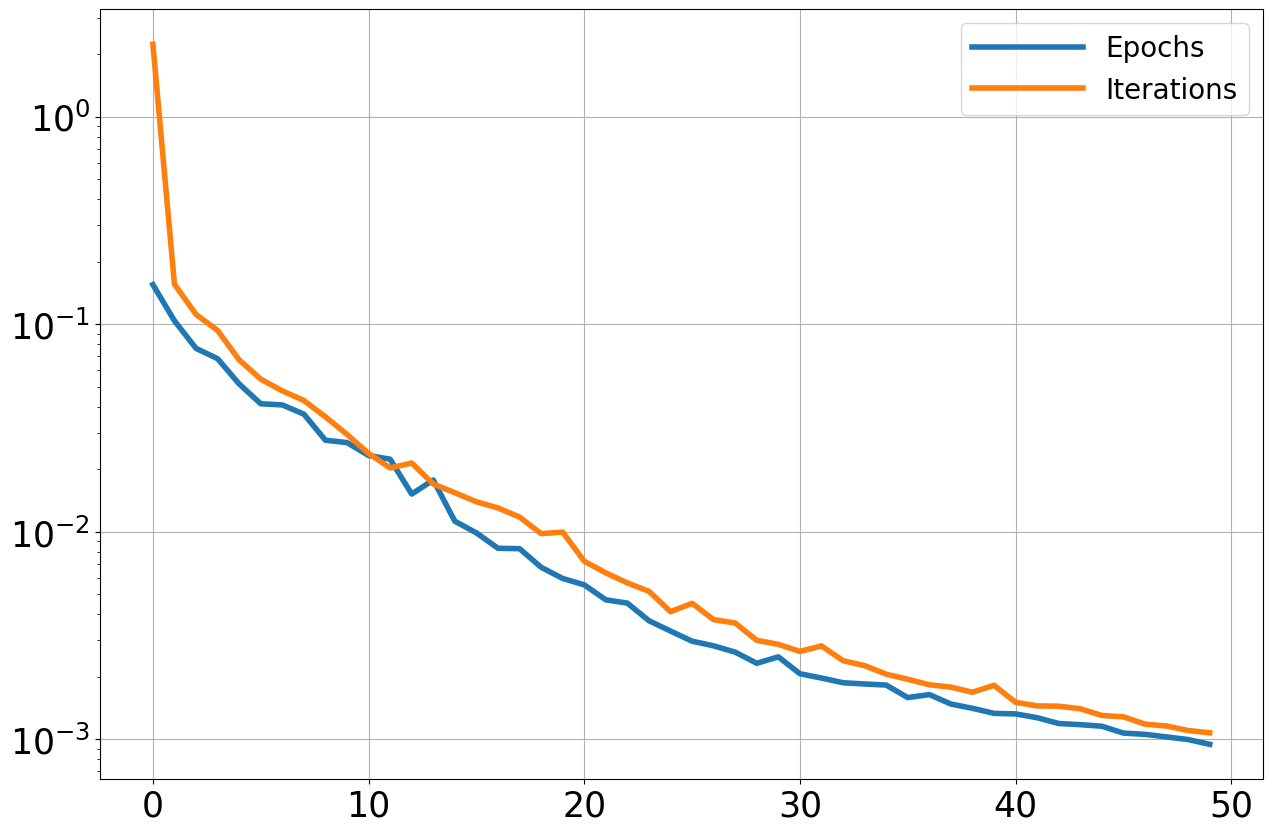

In [134]:
%matplotlib inline
plt.figure(figsize=(15, 10))
plt.semilogy(logs_epochs["iter"], logs_epochs["train_loss"], label="Epochs")
plt.semilogy(logs_iters["train_loss"][::(m//batch_size)], label="Iterations")
plt.legend()
plt.grid()

### 4.2. Размер батча. Двухслойная Модель

In [155]:
batch_size_list = [8, 64, 128, 256, 512]
batch_logs = {}
epochs = 50
for batch_size in batch_size_list:
    print(batch_size)
    model = init_two_layer_model(n).to(device)
    optimizer = SGD_base(model.parameters(), lr=0.05)
    _, batch_logs[batch_size] = train_epochs(model, X.to(device), Y.to(device).view(-1).to(torch.long),
                                             nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size,
                                             X_test=X_test.to(device), Y_test=Y_test.to(device).to(torch.long))

8
64
128
256
512


<Figure size 3000x2000 with 0 Axes>

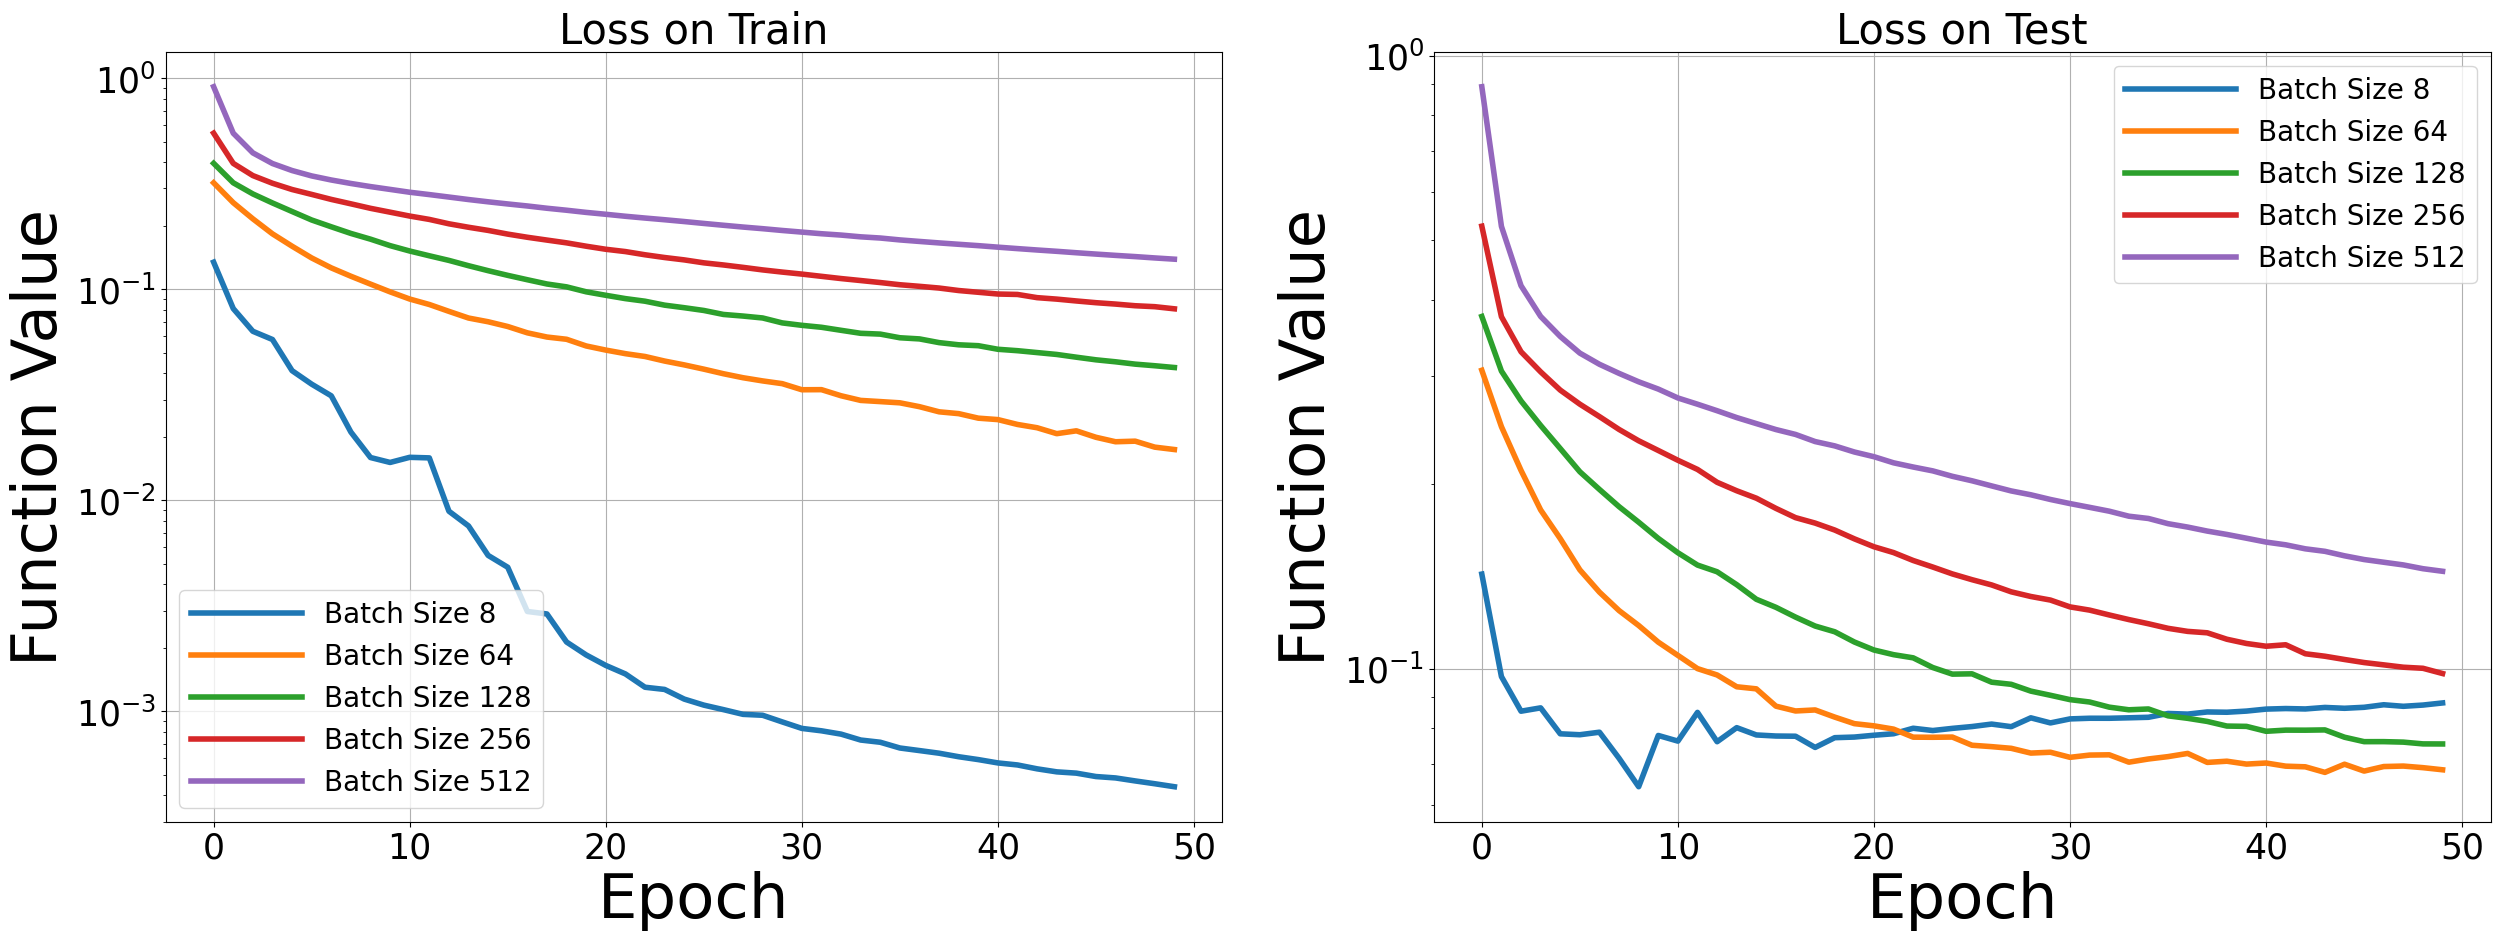

In [156]:
%matplotlib inline
plt.figure(figsize=(30, 20))
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
for batch_size in batch_size_list:
    logs_epochs = batch_logs[batch_size]
    ax[0].semilogy(logs_epochs["iter"], logs_epochs["train_loss"], label="Batch Size %d" % batch_size)
    ax[1].semilogy(logs_epochs["iter"], logs_epochs["test_loss"], label="Batch Size %d" % batch_size)
ax[0].legend()
ax[0].set_ylabel("Function Value")
ax[0].set_xlabel("Epoch")
ax[0].set_title("Loss on Train")
ax[0].grid()
ax[1].legend()
ax[1].set_ylabel("Function Value")
ax[1].set_xlabel("Epoch")
ax[1].set_title("Loss on Test")
ax[1].grid()

<Figure size 3000x2000 with 0 Axes>

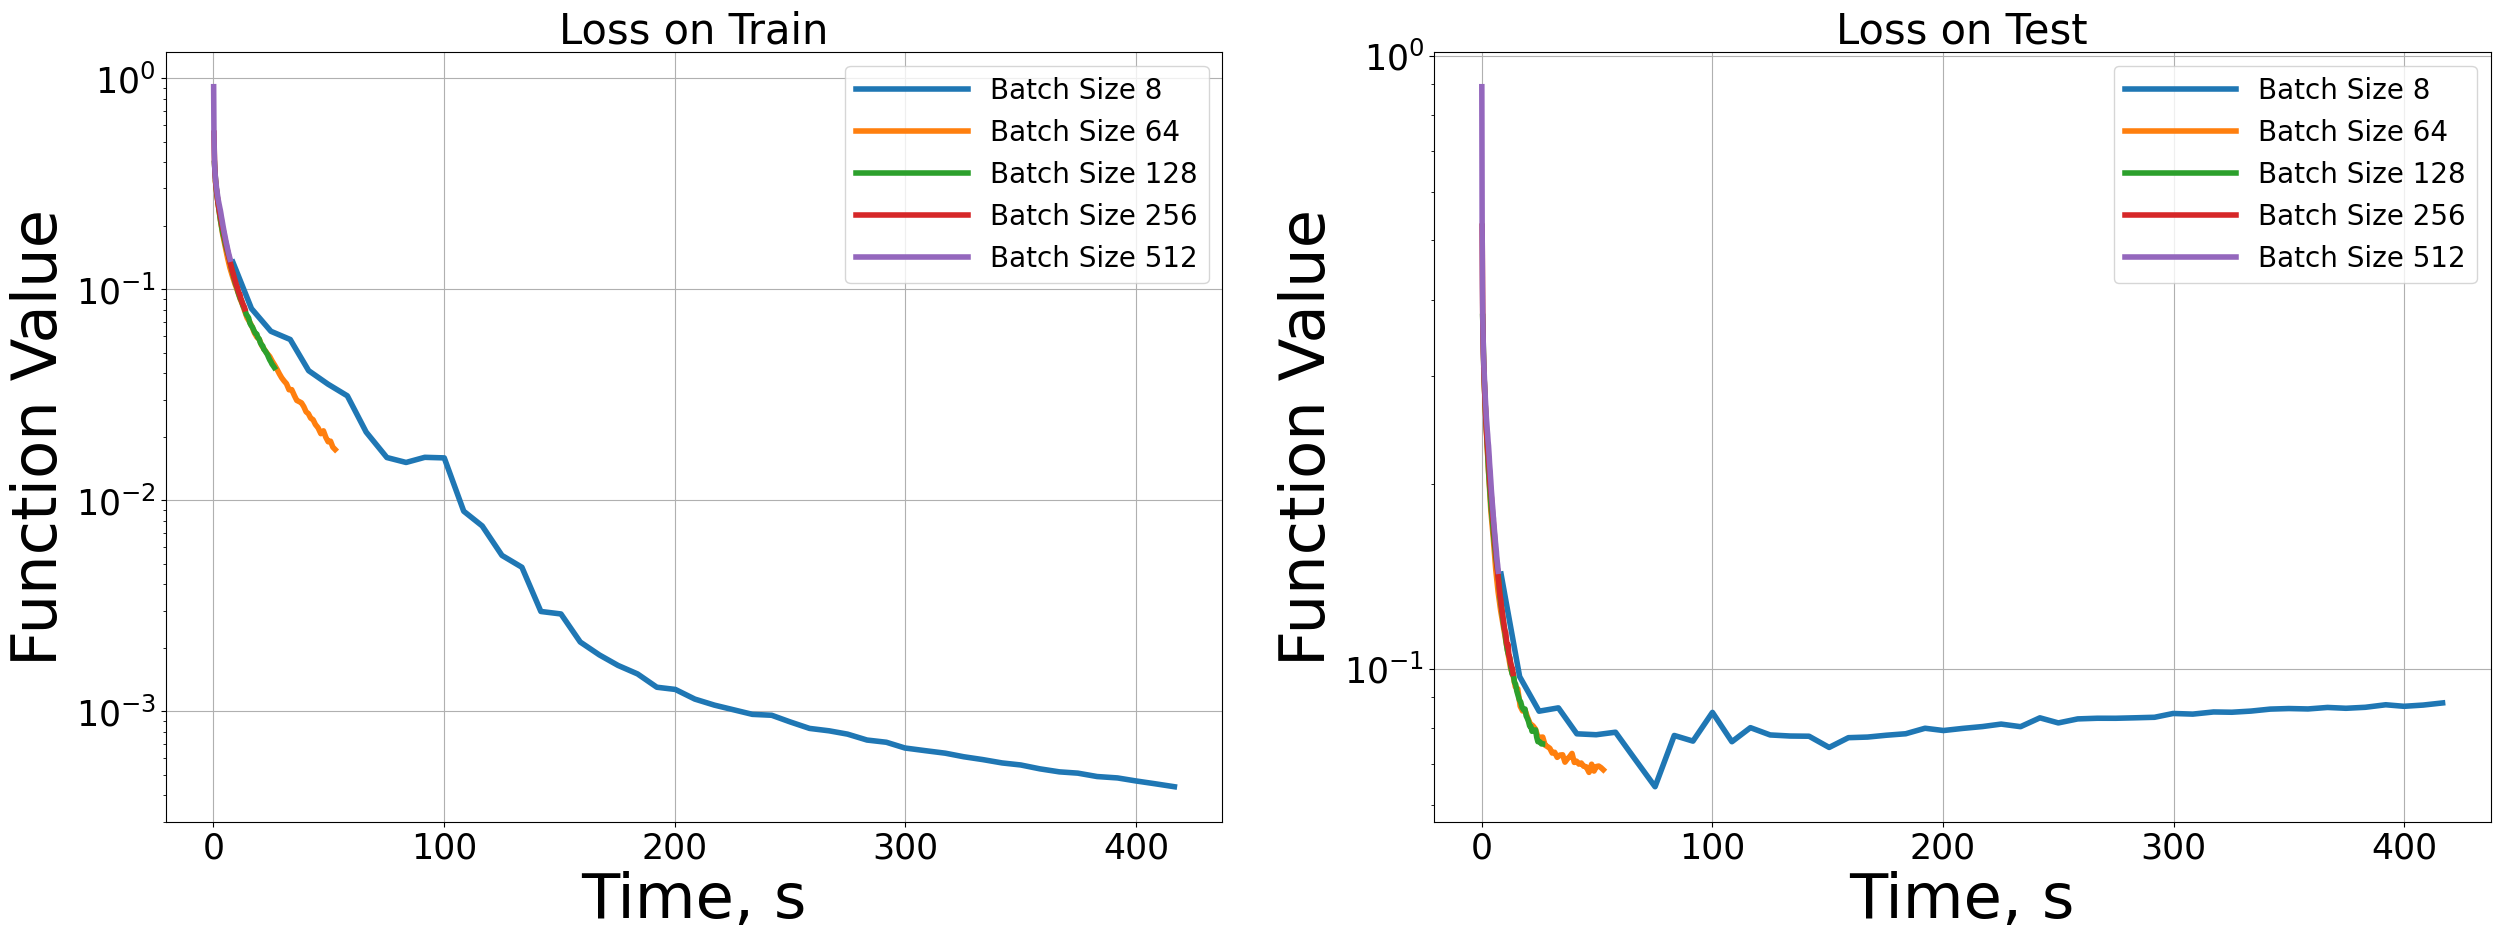

In [157]:
%matplotlib inline
plt.figure(figsize=(30, 20))
fig, ax = plt.subplots(1, 2, figsize=(30, 10))
for batch_size in batch_size_list:
    logs_epochs = batch_logs[batch_size]
    ax[0].semilogy(logs_epochs["time"], logs_epochs["train_loss"], label="Batch Size %d" % batch_size)
    ax[1].semilogy(logs_epochs["time"], logs_epochs["test_loss"], label="Batch Size %d" % batch_size)
ax[0].legend()
ax[0].set_ylabel("Function Value")
ax[0].set_xlabel("Time, s")
ax[0].set_title("Loss on Train")
ax[0].grid()
ax[1].legend()
ax[1].set_ylabel("Function Value")
ax[1].set_xlabel("Time, s")
ax[1].set_title("Loss on Test")
ax[1].grid()

$$\sigma^2_m = Var\left(\frac{\alpha_m}{m}\sum_{i=1}^m \nabla F(x, \xi_i)\right)=\frac{\alpha^2_m}{m^2}\sum_{i=1}^m Var\left(\nabla F(x, \xi_i)\right)\leq \frac{\alpha^2_m\sigma^2}{m}$$


$$\alpha_m \sim \sqrt{m}$$

$$\alpha_m \sim {m}$$

128
128 lr 0.04289690777659416
128 lr*$\sqrt{batchsize}$ 0.029489079490303993
128 lr*batchsize 0.016957731917500496
256
256 lr 0.08069197088479996
256 lr*$\sqrt{batchsize}$ 0.04256436228752136
256 lr*batchsize 0.017362842336297035
512
512 lr 0.13883475959300995
512 lr*$\sqrt{batchsize}$ 0.06002943962812424
512 lr*batchsize 0.017061863094568253


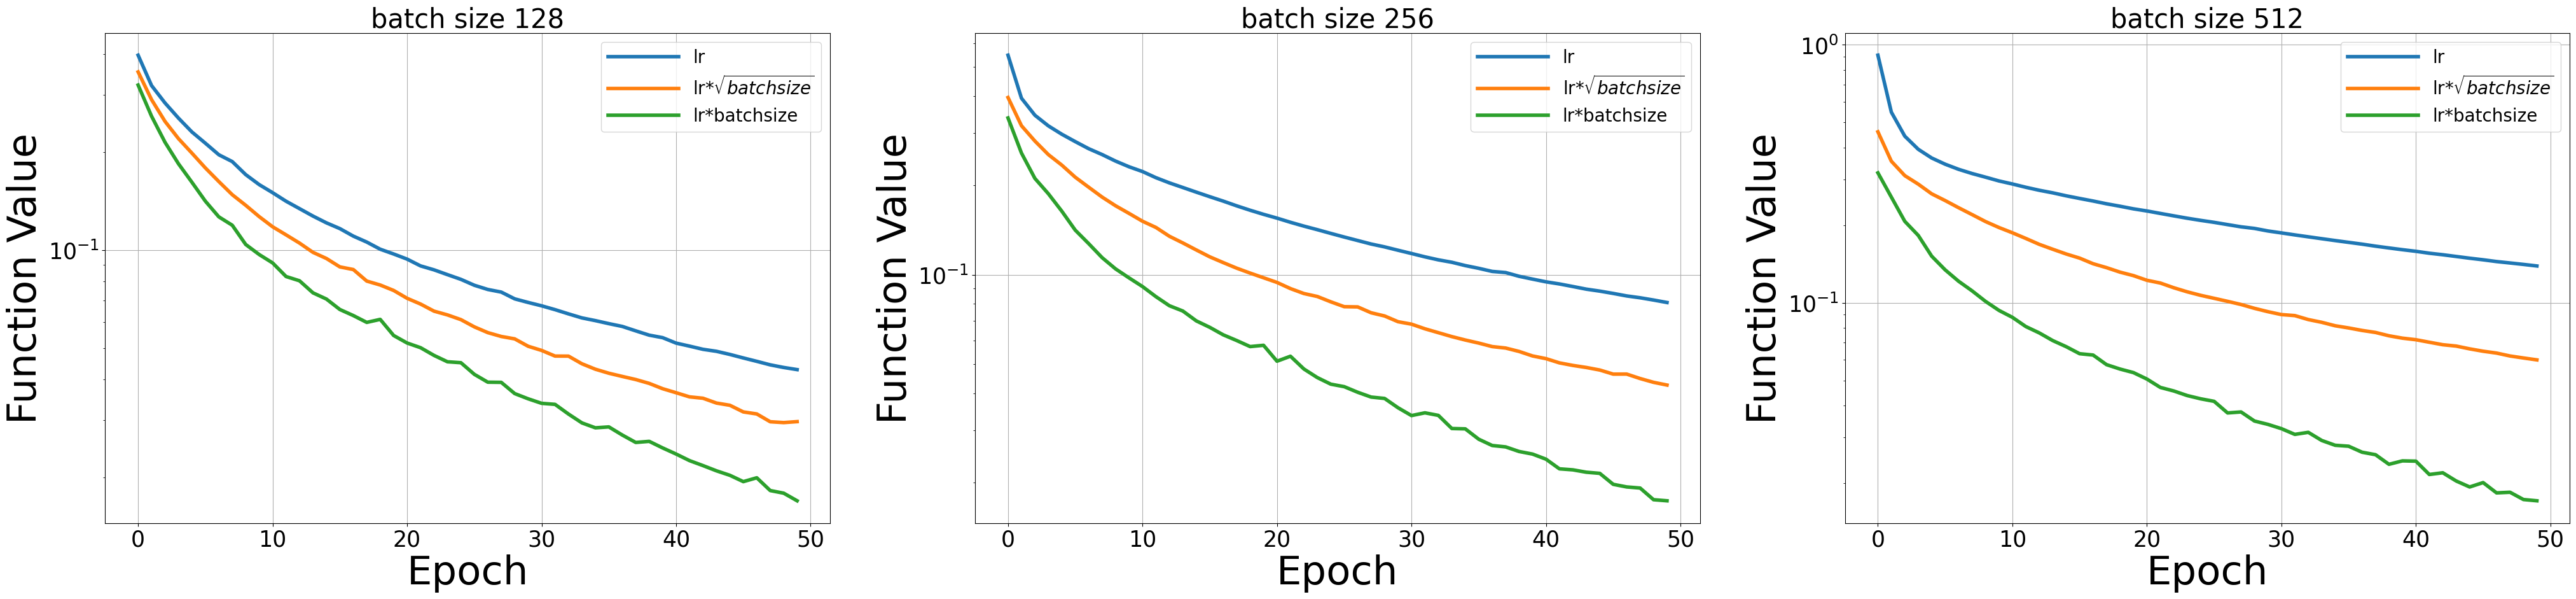

In [158]:
batch_size_list = [128, 256, 512]
batch_logs = {}
epochs = 50
fig, ax = plt.subplots(1, 3, figsize=(50, 10))
ind = 0
lr_policy_list = ["lr", r"lr*$\sqrt{batchsize}$", r"lr*batchsize"]
for batch_size in batch_size_list:
    print(batch_size)
    m = 1
    for lr_policy in lr_policy_list:
        if lr_policy == lr_policy_list[0]:
            m = 1
        elif lr_policy == lr_policy_list[1]:
            m = np.sqrt(batch_size / 64)
        elif lr_policy == lr_policy_list[2]:
            m = (batch_size / 64)
        model = init_two_layer_model(n).to(device)
        optimizer = SGD_base(model.parameters(), lr=0.05 * m)
        _, batch_logs[batch_size] = train_epochs(model, X.to(device), Y.to(device).view(-1).to(torch.long),
                                              nn.CrossEntropyLoss(), epochs, optimizer, batch_size=batch_size,
                                              X_test=X_test.to(device), Y_test=Y_test.to(device).to(torch.long))
        logs_epochs = batch_logs[batch_size]
        print(batch_size, lr_policy, min(logs_epochs["train_loss"]))
        ax[ind].semilogy(logs_epochs["iter"], logs_epochs["train_loss"], label=lr_policy)
    ax[ind].legend()
    ax[ind].set_ylabel("Function Value")
    ax[ind].set_xlabel("Epoch")
    ax[ind].set_title("batch size {}".format(batch_size))
    ax[ind].grid()
    ind += 1
